In [1]:
import pandas as pd

In [8]:
ds = pd.read_csv("Titanic-Dataset.csv")

In [10]:
ds.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
ds.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
ds.fillna(ds["Age"].mean(), inplace=True)
ds.fillna(ds["Cabin"].mode(), inplace=True)
ds.fillna(ds["Embarked"].mode(), inplace=True)
ds.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [16]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
label_encoder = LabelEncoder()
ds["Sex"] = label_encoder.fit_transform(ds["Sex"])
ds = pd.get_dummies(ds, columns=["Embarked"], drop_first=True)
ds.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,29.699118,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,29.699118,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,29.699118,False,False,True


In [22]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int32  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked_C   891 non-null    bool   
 12  Embarked_Q   891 non-null    bool   
 13  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(2), int32(1), int64(5), object(3)
memory usage: 75.8+ KB


In [26]:
data_cleaned = ds.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [28]:
descriptive_stats = data_cleaned.describe()

In [30]:
unique_values = {col: data_cleaned[col].unique() for col in data_cleaned.columns if data_cleaned[col].dtype == 'object'}
descriptive_stats, unique_values

(         Survived      Pclass         Sex         Age       SibSp       Parch  \
 count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
 mean     0.383838    2.308642    0.647587   29.699118    0.523008    0.381594   
 std      0.486592    0.836071    0.477990   13.002015    1.102743    0.806057   
 min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
 25%      0.000000    2.000000    0.000000   22.000000    0.000000    0.000000   
 50%      0.000000    3.000000    1.000000   29.699118    0.000000    0.000000   
 75%      1.000000    3.000000    1.000000   35.000000    1.000000    0.000000   
 max      1.000000    3.000000    1.000000   80.000000    8.000000    6.000000   
 
              Fare  
 count  891.000000  
 mean    32.204208  
 std     49.693429  
 min      0.000000  
 25%      7.910400  
 50%     14.454200  
 75%     31.000000  
 max    512.329200  ,
 {'Cabin': array([29.69911764705882, 'C85', 'C123', 'E46', 'G6', 'C103

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
sns.set(style="whitegrid")

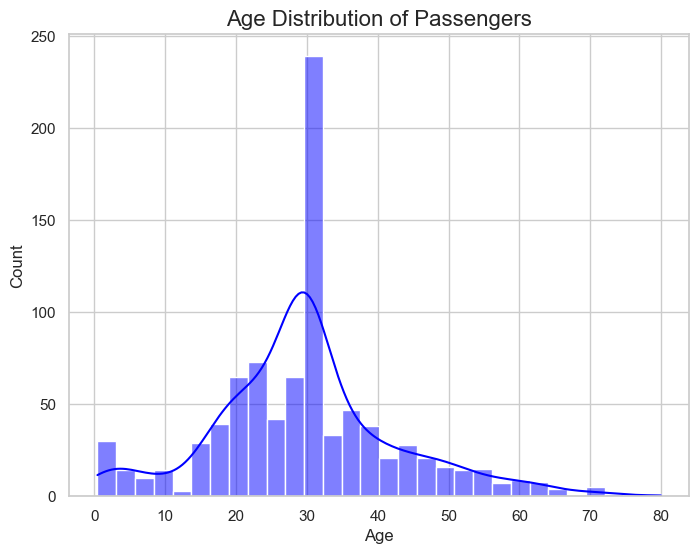

In [36]:
plt.figure(figsize=(8, 6))
sns.histplot(data_cleaned['Age'], kde=True, bins=30, color='blue')
plt.title('Age Distribution of Passengers', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

C:\Users\adesh\AppData\Local\Temp\ipykernel_16616\968015323.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=data_cleaned['Sex'], y=data_cleaned['Survived'], ci=None, palette='viridis')
C:\Users\adesh\AppData\Local\Temp\ipykernel_16616\968015323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_cleaned['Sex'], y=data_cleaned['Survived'], ci=None, palette='viridis')


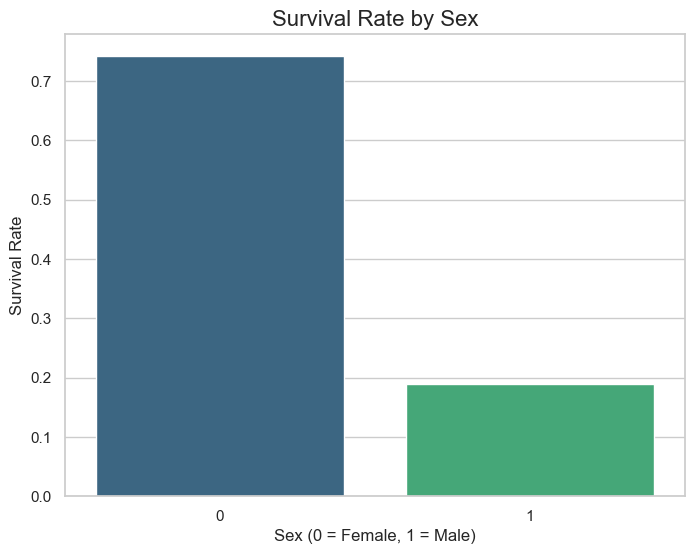

In [38]:
plt.figure(figsize=(8, 6))
sns.barplot(x=data_cleaned['Sex'], y=data_cleaned['Survived'], ci=None, palette='viridis')
plt.title('Survival Rate by Sex', fontsize=16)
plt.xlabel('Sex (0 = Female, 1 = Male)', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

C:\Users\adesh\AppData\Local\Temp\ipykernel_16616\888284352.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=data_cleaned['Pclass'], y=data_cleaned['Survived'], ci=None, palette='muted')
C:\Users\adesh\AppData\Local\Temp\ipykernel_16616\888284352.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_cleaned['Pclass'], y=data_cleaned['Survived'], ci=None, palette='muted')


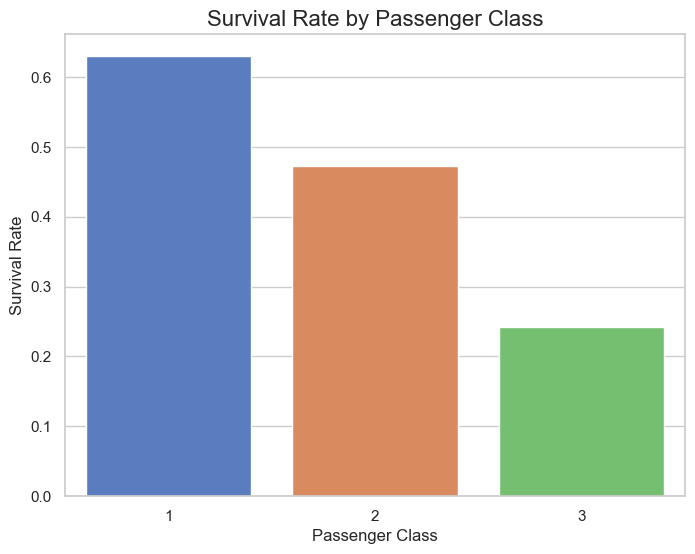

In [40]:
plt.figure(figsize=(8, 6))
sns.barplot(x=data_cleaned['Pclass'], y=data_cleaned['Survived'], ci=None, palette='muted')
plt.title('Survival Rate by Passenger Class', fontsize=16)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.show()

C:\Users\adesh\AppData\Local\Temp\ipykernel_16616\3385641744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_cleaned['Survived'], y=data_cleaned['Fare'], palette='coolwarm')


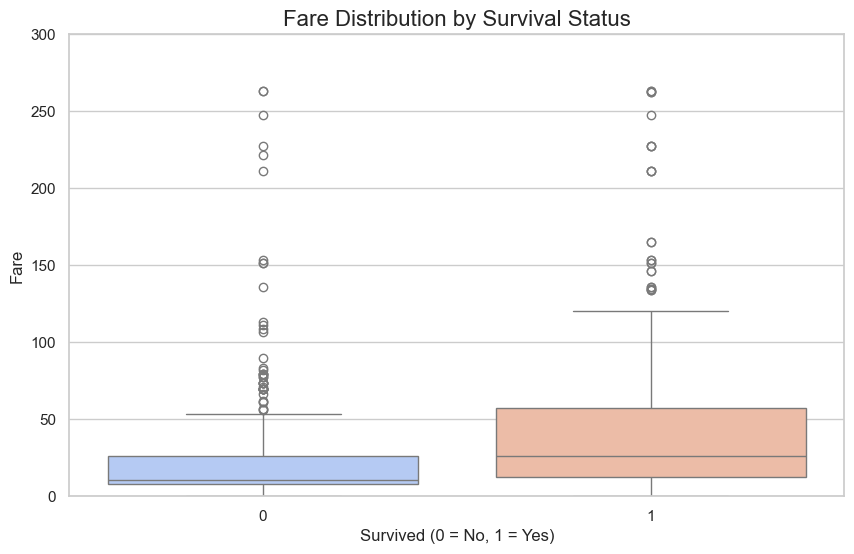

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_cleaned['Survived'], y=data_cleaned['Fare'], palette='coolwarm')
plt.title('Fare Distribution by Survival Status', fontsize=16)
plt.xlabel('Survived (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.ylim(0, 300)
plt.show()